<a href="https://colab.research.google.com/github/Muse-M/FinalYearProject/blob/main/QSO_%2B_Many_gal_%2B_Noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

should I predict gal type still?
- Note the way there are multiple dataloaders to get the data in the correct format for each type of model is VERY VERY janky.
    - Need to standerdise the masterDataset class so each model is reciving the same training set

- need to add early stopping

## Imports

In [1]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 23.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling n

In [2]:
# Pytorch imports
import torch
import torch.utils.data as data
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import captum
from captum.attr import (
    GradientShap,
    DeepLift,
    DeepLiftShap,
    IntegratedGradients,
    LayerConductance,
    NeuronConductance,
    NoiseTunnel)

# General Python imports
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif" # Standardise font throughout whole notebook
from   matplotlib.ticker import AutoMinorLocator
import seaborn as sns
import numpy as np
import os
import pandas as pd
import pickle
from datetime import datetime
import joblib

# Quality of life imports
from tqdm.notebook import tqdm # progress Bar
from accelerate import Accelerator

# data processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Import tensorboard logger from PyTorch
from torch.utils.tensorboard import SummaryWriter
# Load tensorboard extension for Jupyter Notebook, only need to start TB in the notebook
%load_ext tensorboard

In [3]:
################UoA code################
torch.manual_seed(42) # Setting the seed

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device cuda


## data load

In [4]:
dataPath='/content/drive/MyDrive/many qso + many gal + noise 2'
filePaths=[]
for i in os.listdir(dataPath):
  filePaths.append(os.path.join(dataPath, i))


In [5]:
from functools import total_ordering
from concurrent.futures import ThreadPoolExecutor

def load_pickle(file_path ):
    a=filePaths.index(file_path)
    if a%1000==0:
        print(str(a)+'/10000')
    with open(file_path, "rb") as f:
        try:
            data = pickle.load(f)
            data['wl'] = data['wl'].flatten()
            df=pd.DataFrame(data)
            df_single_row = pd.DataFrame({col: [df[col].tolist()] for col in df.columns})
            return df_single_row
        except Exception as e:
            print(f"Error loading file: {file_path[len(dataPath):]} | {e}")

# Load files in parallel
# Loads each pickle file from drive as a dataframe with 1 row and adds to list dataframes
with ThreadPoolExecutor() as executor:
    dataframes = list(executor.map(load_pickle, filePaths))



# concatenate all dataframes into 1 dataframe
final_df = pd.concat(dataframes, ignore_index=True)
final_df.shape

0/10000
1000/10000
2000/10000
3000/10000
4000/10000
5000/10000
6000/10000
7000/10000
8000/10000
9000/10000


(10000, 9)

In [6]:
final_df.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...","[red, red, red, red, red, red, red, red, red, ...","[0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.2...","[1.9055955462768537, 1.9055955462768537, 1.905...","[-1.466245245968707, -1.466245245968707, -1.46..."
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...","[red, red, red, red, red, red, red, red, red, ...","[0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.7...","[1.8962762902563093, 1.8962762902563093, 1.896...","[-1.5121581382752982, -1.5121581382752982, -1...."
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...","[red, red, red, red, red, red, red, red, red, ...","[0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.8...","[1.9228175140027075, 1.9228175140027075, 1.922...","[-1.2747974793001169, -1.2747974793001169, -1...."
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...","[red, red, red, red, red, red, red, red, red, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[1.81027654592034, 1.81027654592034, 1.8102765...","[-0.8497407749135834, -0.8497407749135834, -0...."
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...","[red, red, red, red, red, red, red, red, red, ...","[0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.7...","[1.9166287600600451, 1.9166287600600451, 1.916...","[-1.532779964391233, -1.532779964391233, -1.53..."


In [7]:
firstDataset=final_df.copy(deep=True)
# converts columns that should be single valued into single values i.e [0.01,0.01,0.01....] => 0.01
firstDataset['f_gal'] = firstDataset['f_gal'].apply(lambda x: x[0])
firstDataset['gal_type'] = firstDataset['gal_type'].apply(lambda x: x[0])
firstDataset['dn4000'] = firstDataset['dn4000'].apply(lambda x: x[0])
firstDataset['hdelta'] = firstDataset['hdelta'].apply(lambda x: x[0])


# transforms categorical gal_types into numeric
le = LabelEncoder()
firstDataset['gal_type_code'] = le.fit_transform(firstDataset['gal_type'])

In [8]:
firstDataset.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta,gal_type_code
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...",red,0.22,1.905596,-1.466245,4
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...",red,0.74,1.896276,-1.512158,4
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...",red,0.86,1.922818,-1.274797,4
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...",red,0.10,1.810277,-0.849741,4
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...",red,0.71,1.916629,-1.532780,4


<Axes: >

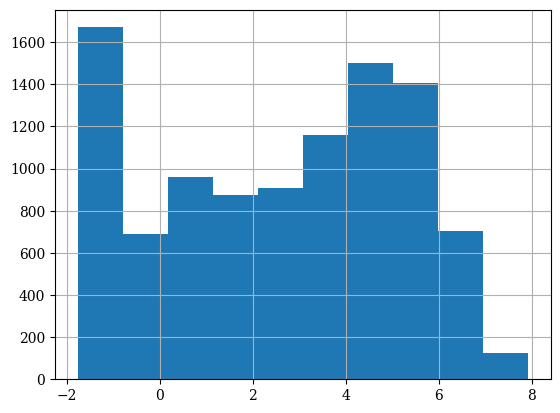

In [9]:
firstDataset['hdelta'].hist()

<Axes: >

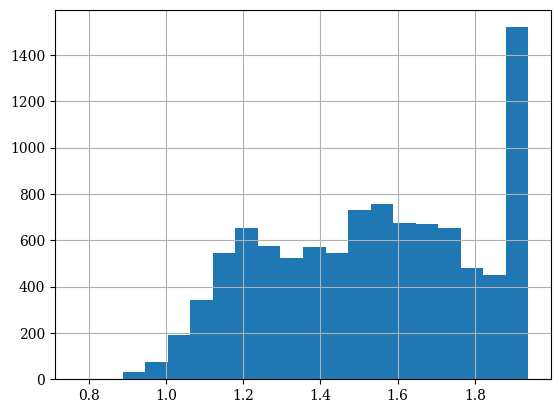

In [226]:
firstDataset['dn4000'].hist(bins=20)

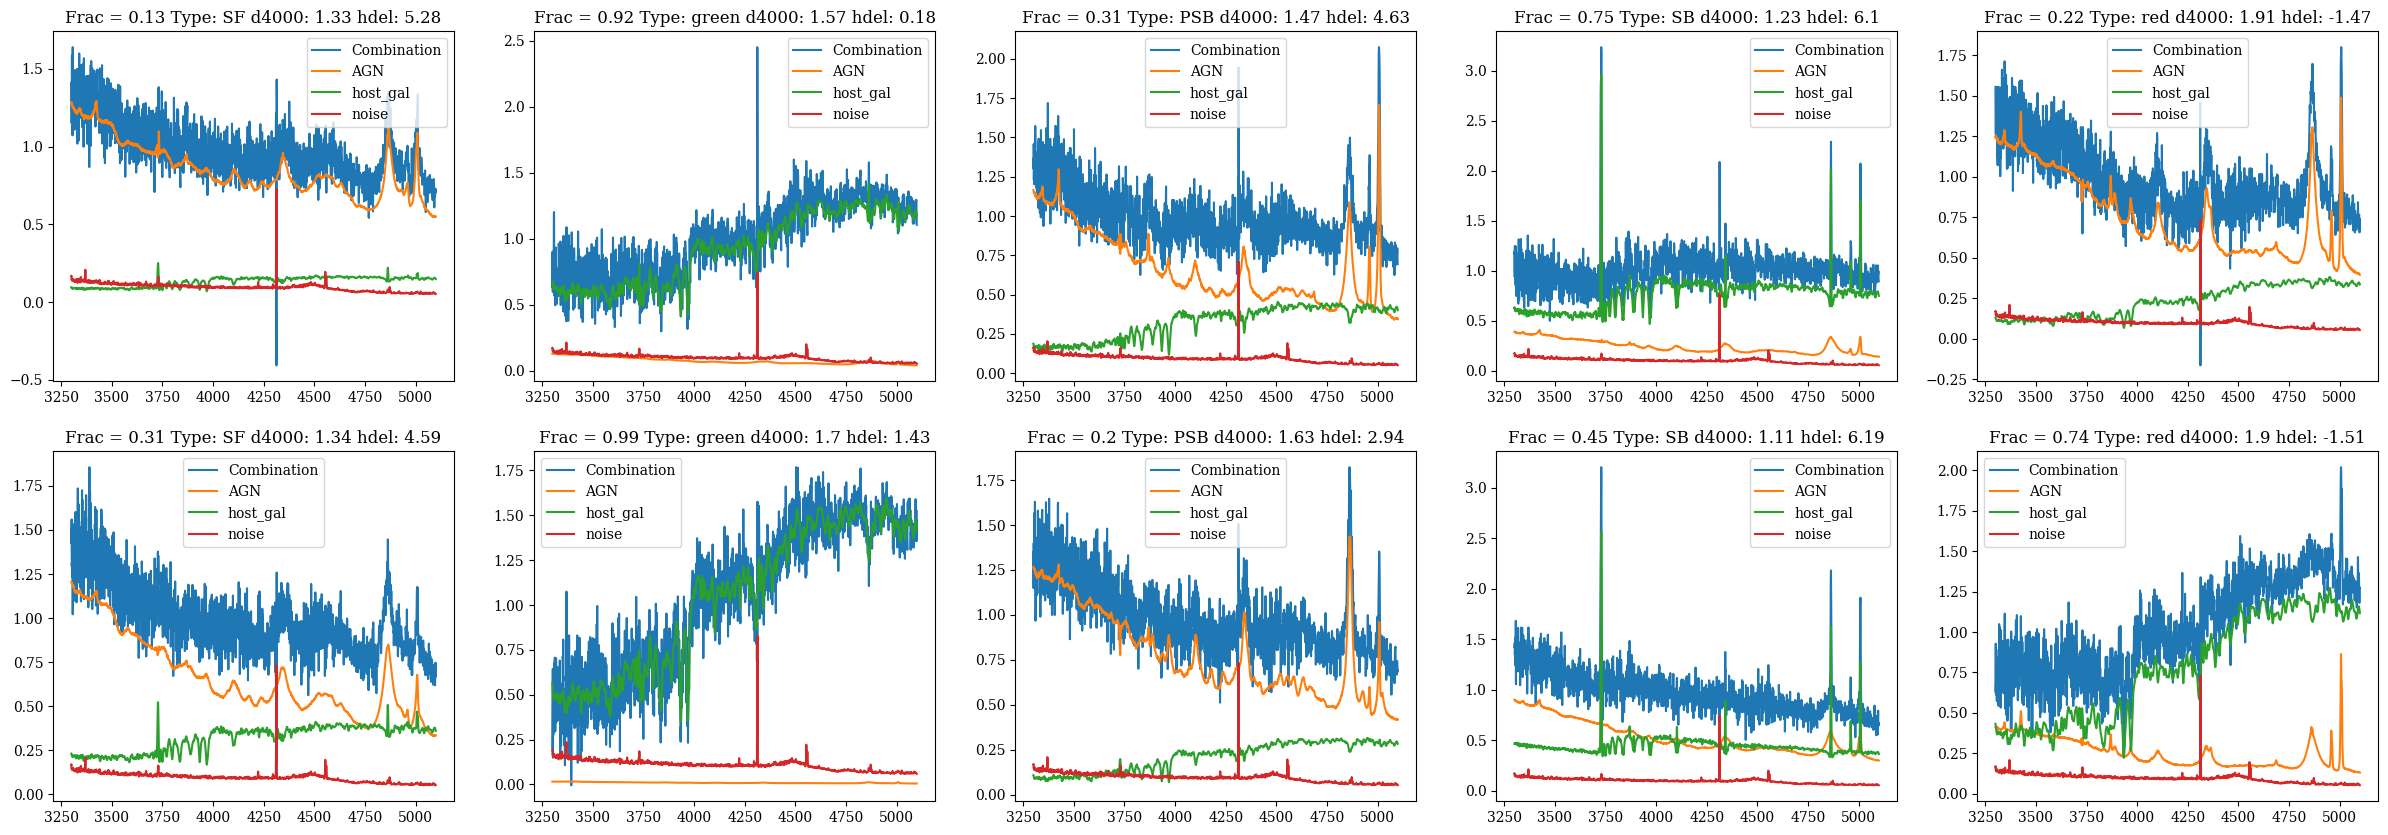

In [11]:
types= ['SF',  'green', 'PSB', 'SB', 'red']
fig, ax = plt.subplots(figsize=(30,10), ncols=5, nrows=2)
uniqueType=[]

i=0
graph=0

while len(uniqueType) < 10: # plot spectra if that gal_type is new
    singleRow=firstDataset.iloc[[i]]
    wl= singleRow['wl'].iloc[0]
    flux= singleRow['flux'].iloc[0]
    true_AGN= singleRow['true_AGN'].iloc[0]
    true_gal= singleRow['true_gal'].iloc[0]
    noise_array=singleRow['error'].iloc[0]
    gal_type=singleRow['gal_type'].iloc[0]
    f_gal= singleRow['f_gal'].iloc[0]
    d4000= singleRow['dn4000'].iloc[0]
    hdel= singleRow['hdelta'].iloc[0]

    i+=1

    typecount=uniqueType.count(gal_type)

    if typecount>=2:
        pass
    else:
        ax[typecount,types.index(gal_type)].plot(wl, flux, label='Combination')
        ax[typecount,types.index(gal_type)].plot(wl, true_AGN, label='AGN')
        ax[typecount,types.index(gal_type)].plot(wl, true_gal, label='host_gal')
        ax[typecount,types.index(gal_type)].plot(wl, noise_array, label='noise')
        ax[typecount,types.index(gal_type)].set_title('Frac = '+str(f_gal)+ ' Type: '+ gal_type + ' d4000: ' +str(round(d4000,2)) + ' hdel: ' + str(round(hdel,2)))
        ax[typecount,types.index(gal_type)].legend()
        if typecount==1:
            graph+=1
        uniqueType.append(gal_type)




### make dataloaders for the simul traning model


In [12]:
# Dataset class for simultaneous traning model
class fullDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, fraction, galTypeCode,dn4000,hdelta):
    self.data=flux
    self.f_gal=fraction
    self.galTypeCode=galTypeCode
    self.dn4=dn4000
    self.hdelta=hdelta
    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorF_gal=torch.Tensor(self.f_gal)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)
    self.tensordn4=torch.Tensor(self.dn4)
    self.tensorhdel=torch.Tensor(self.hdelta)


  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorF_gal[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    dn4_indexed = self.tensordn4[index]
    hdelta_indexed = self.tensorhdel[index]

    return data_point, data_f_gal, gal_typeCode, dn4_indexed,hdelta_indexed

  def  __len__(self):
    return self.size

#create dataset
fullDataset_simul_traning=fullDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'],firstDataset['dn4000'],firstDataset['hdelta'])

In [13]:
#split data set into train, validation, test (8800,200,1000)
trainDataset, testDataset = torch.utils.data.random_split(fullDataset_simul_traning, [9000,1000])
trainDataset, validDataset = torch.utils.data.random_split(trainDataset, [8800,200])

In [14]:
import torch.utils.data as data
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in

TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100
train_data_loader = data.DataLoader(trainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=False)

In [15]:
for batch_flux, batch_f_gal,batch_galType_code, batch_dn4, batch_hdel in train_data_loader:
    print(batch_flux, batch_f_gal,batch_galType_code, batch_dn4, batch_hdel)
    break

tensor([[0.9686, 0.4948, 0.9471,  ..., 1.2115, 1.1104, 1.1828],
        [1.9363, 1.8064, 1.8095,  ..., 0.4449, 0.3347, 0.5380],
        [1.4573, 1.4715, 1.7817,  ..., 0.5981, 0.5515, 0.5707],
        ...,
        [1.3208, 1.3780, 1.3459,  ..., 0.8968, 0.8725, 0.9067],
        [1.2045, 1.1437, 1.3998,  ..., 0.6689, 0.7606, 0.6783],
        [1.1964, 1.0763, 1.0374,  ..., 0.8915, 1.0118, 0.9889]]) tensor([0.8100, 0.0200, 0.4100, 0.9600, 0.6300, 0.5400, 0.6200, 0.3800, 0.1100,
        0.5700, 0.7200, 0.8500, 0.5100, 0.5900, 0.7200, 0.1900, 0.6200, 0.2800,
        0.1300, 0.5700, 0.8100, 0.6200, 0.9500, 0.9200, 0.8900, 0.3900, 0.2600,
        0.7800, 0.7100, 0.1400, 0.0200, 0.4900, 0.6200, 0.7400, 0.5400, 0.4800,
        0.4800, 0.4400, 0.0500, 0.4600]) tensor([0., 1., 1., 1., 4., 1., 2., 1., 0., 0., 3., 1., 2., 3., 3., 1., 4., 1.,
        2., 2., 0., 0., 3., 2., 4., 3., 2., 1., 3., 4., 4., 4., 3., 3., 3., 4.,
        1., 3., 4., 4.]) tensor([1.5032, 1.1415, 1.0729, 1.0502, 1.8373, 0.9335, 

### Make datset for the individual training

In [16]:
# Dataset class for individual traning model
class individualDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, label, type_hue):
    self.data=flux
    self.label=label
    self.hue=type_hue

    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorLabel=torch.Tensor(self.label)
    self.tensorHue=torch.Tensor(self.hue)

  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_label = self.tensorLabel[index]
    data_hue = self.tensorHue[index]


    return data_point, data_label, data_hue

  def  __len__(self):
    return self.size

#create dataset
f_gal_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'])
dn4000_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['dn4000'],firstDataset['gal_type_code'])
hdelta_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['hdelta'],firstDataset['gal_type_code'])

In [17]:
trainDataset_f_gal, testDataset_f_gal = torch.utils.data.random_split(f_gal_dataset, [9000,1000])
trainDataset_f_gal, validDataset_f_gal = torch.utils.data.random_split(trainDataset_f_gal, [8800,200])

trainDataset_dn4, testDataset_dn4 = torch.utils.data.random_split(dn4000_dataset, [9000,1000])
trainDataset_dn4, validDataset_dn4 = torch.utils.data.random_split(trainDataset_dn4, [8800,200])

trainDataset_hdel, testDataset_hdel = torch.utils.data.random_split(hdelta_dataset, [9000,1000])
trainDataset_hdel, validDataset_hdel = torch.utils.data.random_split(trainDataset_hdel, [8800,200])

In [18]:
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100

train_data_loader_fgal = data.DataLoader(trainDataset_f_gal, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_fgal = data.DataLoader(validDataset_f_gal, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_fgal = data.DataLoader(testDataset_f_gal, batch_size=500, shuffle=False)

train_data_loader_dn4 = data.DataLoader(trainDataset_dn4, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4 = data.DataLoader(validDataset_dn4, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_dn4= data.DataLoader(testDataset_dn4, batch_size=500, shuffle=False)

train_data_loader_hdelta = data.DataLoader(trainDataset_hdel, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta = data.DataLoader(validDataset_hdel, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_hdelta = data.DataLoader(testDataset_hdel, batch_size=500, shuffle=False)


## ResNet50 Model

### Class

In [19]:
class singleBlock(nn.Module):
    def __init__(self, input_ch, output_ch, kernel, stride):
        super().__init__()

        pad=int((kernel-1)/2)
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.bn=nn.BatchNorm1d(output_ch)

    def forward(self, x):
        x= self.conv(x)
        x= self.bn(x)
        return x


class residualBlock(nn.Module):
    def __init__(self, input_ch, output_ch, downsample,firstLayerInBlock, stride, bottleNeckRequired):
        super().__init__()

        if firstLayerInBlock:
            downSampleFactor=2
            self.input_ch=int(input_ch/2)
        else:
            downSampleFactor=4
            self.input_ch=input_ch


        self.output_ch=output_ch
        if bottleNeckRequired:
            self.bottleNeckChannelSize=int(self.input_ch/downSampleFactor)
        else:
            self.bottleNeckChannelSize=self.input_ch

        self.conv1=singleBlock(self.input_ch, self.bottleNeckChannelSize, 1, 1)
        self.conv2=singleBlock(self.bottleNeckChannelSize,self.bottleNeckChannelSize,3,stride)
        self.conv3=singleBlock(self.bottleNeckChannelSize, self.output_ch,1,1)
        self.act= nn.ReLU()

        self.downsample=downsample
        if self.input_ch != self.output_ch:
            self.downsample=True
        if self.downsample:
            self.downsampleConv=singleBlock(self.input_ch, self.output_ch, 1,stride)

    def forward(self, x):

        f=self.act(self.conv1(x))
        f=self.act(self.conv2(f))
        f=self.conv3(f)

        if self.downsample:
            x=self.downsampleConv(x)

        h=f+x
        return self.act(h)



class fullResNetModel50(nn.Module):
    def __init__(self, dataChannels, blockList, channelList, finalOutputNo, bottleNeckRequired, stride, chainNumber, **kwargs):
        super().__init__()

        self.blockList=blockList
        self.channelList=channelList
        self.classes=finalOutputNo
        self.stride=stride
        self.chainNumber=chainNumber

        self.firstConv=nn.Conv1d(dataChannels, self.channelList[0], 3,2,3)
        self.BN=nn.BatchNorm1d(self.channelList[0])
        self.act=nn.ReLU()
        self.maxPool=nn.MaxPool1d(3,2,1)

        if self.channelList[0] != self.channelList[1]:
            # takes output from input layer and increase number of channels to size needed to make sure it can add with the first block of middle layers
            self.middleLayerFirstPartUpsample=nn.Conv1d(self.channelList[0], self.channelList[1], 1,1,0)

        self.bottleNeckRequired=bottleNeckRequired # if high number of filters, downsample is needed at the start of layers


        self._createNetwork()
        self._initWeights()


    def _createNetwork(self):
        self.inputLayer=nn.Sequential(
            self.firstConv,
            self.BN,
            self.act,
            self.maxPool
        )



        self.middleLayersPart1=nn.Sequential(
            singleBlock(self.channelList[0], self.channelList[0], 1, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0],self.channelList[0], 3, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0], self.channelList[1], 1, 1),
        )

        self.blockList[1]=self.blockList[1]-1

        self.middleLayersPart2=nn.Sequential()

        for layer in range(1,len(self.blockList)):
            for i in range(self.blockList[layer]):
                #print('layer', layer, 'block', i)

                firstLayerInBlock = True if (i==0 and layer !=1 and self.channelList[layer] != self.channelList[layer-1] ) else False
                stride=self.stride[layer]
                downsample=True if stride == 2 else False # required when size of input and output dont match, which is when stride isnt 1 or inbetween different residual block, the second case is checked in the class

                self.middleLayersPart2.add_module(str(layer)+' '+str(i),
                                                  residualBlock(self.channelList[layer],
                                                                self.channelList[layer],
                                                                downsample,
                                                                firstLayerInBlock,
                                                                stride,
                                                                self.bottleNeckRequired))

                self.outputLayerAvgPool=nn.AdaptiveAvgPool1d(1)
                self.outputflattenLayer=nn.Flatten()
                self.outputFC=nn.Linear(self.channelList[-1]+self.chainNumber, self.classes)




    def _initWeights(self):
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
            elif (isinstance(m, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, previousPredictions=None):
        x=self.inputLayer(x)
        identity=x
        x=self.middleLayersPart1(x) # first block of first layer in middle part

        if self.channelList[0] != self.channelList[1]:
            identity=self.middleLayerFirstPartUpsample(identity)
        x=identity+x
        x=self.act(x)

        x=self.middleLayersPart2(x)
        x=self.outputLayerAvgPool(x) # 1 value per channel
        x=self.outputflattenLayer(x) # flatten to 1 dim

        if previousPredictions != None:
            x=torch.cat((x,previousPredictions), dim=1) # concat the predictions from earlier models

        x=self.outputFC(x)
        return x


## Individual CNNs

In [59]:
def trainModelResNet(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times

    train_loss_curve=[]
    valid_loss_curve=[]
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        for batch_data, batch_label, _ in traindataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item() # per batch

        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss+=validate_model(model, validdataLoader, lossCalculator) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


        train_loss_curve.append(epoch_train_loss)
        valid_loss_curve.append(epoch_valid_loss)

    return train_loss_curve, valid_loss_curve


def validate_model(model, validdataLoader, lossCalculator):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        for batch_data, batch_label, _ in validdataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()

            lossValue+=lossCalculator(prediction, batch_label).item()

        lossValue /= len(validdataLoader)
    return lossValue

In [60]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_indv=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)


In [61]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4_indv=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

In [62]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_indv=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

In [63]:
optimiser= torch.optim.SGD(model_fgal_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_indv.to(device)
loss= nn.MSELoss()
M1_fgal_trainLossCurve,M1_fgal_validLossCurve=trainModelResNet(model_fgal_indv, train_data_loader_fgal, valid_data_loader_fgal, optimiser,
                                                     loss, 100, lrScheduler,verbose=True)


optimiser= torch.optim.SGD(model_dn4_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')
model_dn4_indv.to(device)
loss= nn.MSELoss()
M1_dn4_trainLossCurve,M1_dn4_validLossCurve=trainModelResNet(model_dn4_indv, train_data_loader_dn4, valid_data_loader_dn4, optimiser,
                 loss, 100, lrScheduler,verbose=True)


optimiser= torch.optim.SGD(model_hdelta_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')
model_hdelta_indv.to(device)
loss= nn.MSELoss()
M1_hdelta_trainLossCurve,M1_hdelta_validLossCurve=trainModelResNet(model_hdelta_indv, train_data_loader_hdelta, valid_data_loader_hdelta, optimiser,
                 loss, 100, lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.055357921352102 Valid loss: 0.02375619951635599 lr 0.001
Epoch No: 11 Train loss:  0.01039164451120252 Valid loss: 0.007288316963240504 lr 0.001
Epoch No: 21 Train loss:  0.008573892858641392 Valid loss: 0.006495559820905328 lr 0.001
Epoch No: 31 Train loss:  0.007723192996557124 Valid loss: 0.007357299327850342 lr 0.001
Epoch No: 41 Train loss:  0.0068228558700701054 Valid loss: 0.006197021575644612 lr 0.001
Epoch No: 51 Train loss:  0.006688022243113003 Valid loss: 0.005718255648389459 lr 0.001
Epoch No: 61 Train loss:  0.006264415585478259 Valid loss: 0.006145100807771087 lr 0.001
Epoch No: 71 Train loss:  0.005946677783504129 Valid loss: 0.006141934776678681 lr 0.001
Epoch No: 81 Train loss:  0.005777940775310113 Valid loss: 0.004965140949934721 lr 0.001
Epoch No: 91 Train loss:  0.005302729406817393 Valid loss: 0.00827772356569767 lr 0.001


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.1443625202825801 Valid loss: 0.04944420978426933 lr 0.001
Epoch No: 11 Train loss:  0.028695408640090715 Valid loss: 0.026029755361378193 lr 0.001
Epoch No: 21 Train loss:  0.02518099383027716 Valid loss: 0.025534321554005146 lr 0.001
Epoch No: 31 Train loss:  0.023716258647089653 Valid loss: 0.029625325463712215 lr 0.001
Epoch No: 41 Train loss:  0.02284841362640939 Valid loss: 0.025361754931509495 lr 0.0001
Epoch No: 51 Train loss:  0.02299286179583181 Valid loss: 0.02563414443284273 lr 0.0001
Epoch No: 61 Train loss:  0.022305992448871787 Valid loss: 0.02481736335903406 lr 1e-05
Epoch No: 71 Train loss:  0.02251091719689694 Valid loss: 0.024133754894137383 lr 1.0000000000000002e-06
Epoch No: 81 Train loss:  0.022444908841597763 Valid loss: 0.025898645631968975 lr 1.0000000000000002e-07
Epoch No: 91 Train loss:  0.022573657583614643 Valid loss: 0.024328124709427357 lr 1.0000000000000004e-08


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  4.65838186415759 Valid loss: 18.784232139587402 lr 0.001
Epoch No: 11 Train loss:  1.8376102363521403 Valid loss: 2.3253090381622314 lr 0.001
Epoch No: 21 Train loss:  1.2654871295798908 Valid loss: 3.7940529584884644 lr 0.001
Epoch No: 31 Train loss:  0.5206123885105957 Valid loss: 2.546008348464966 lr 0.0001
Epoch No: 41 Train loss:  0.36413958048955963 Valid loss: 2.4520394802093506 lr 1e-05
Epoch No: 51 Train loss:  0.3549570596353574 Valid loss: 2.3899590969085693 lr 1.0000000000000002e-06
Epoch No: 61 Train loss:  0.37016781934282994 Valid loss: 2.4297295808792114 lr 1.0000000000000002e-06
Epoch No: 71 Train loss:  0.36048374308103864 Valid loss: 2.393613815307617 lr 1.0000000000000002e-07
Epoch No: 81 Train loss:  0.37168214470148087 Valid loss: 3.250049591064453 lr 1.0000000000000004e-08
Epoch No: 91 Train loss:  0.3430127596313303 Valid loss: 2.370067834854126 lr 1.0000000000000004e-08


#### loss curves

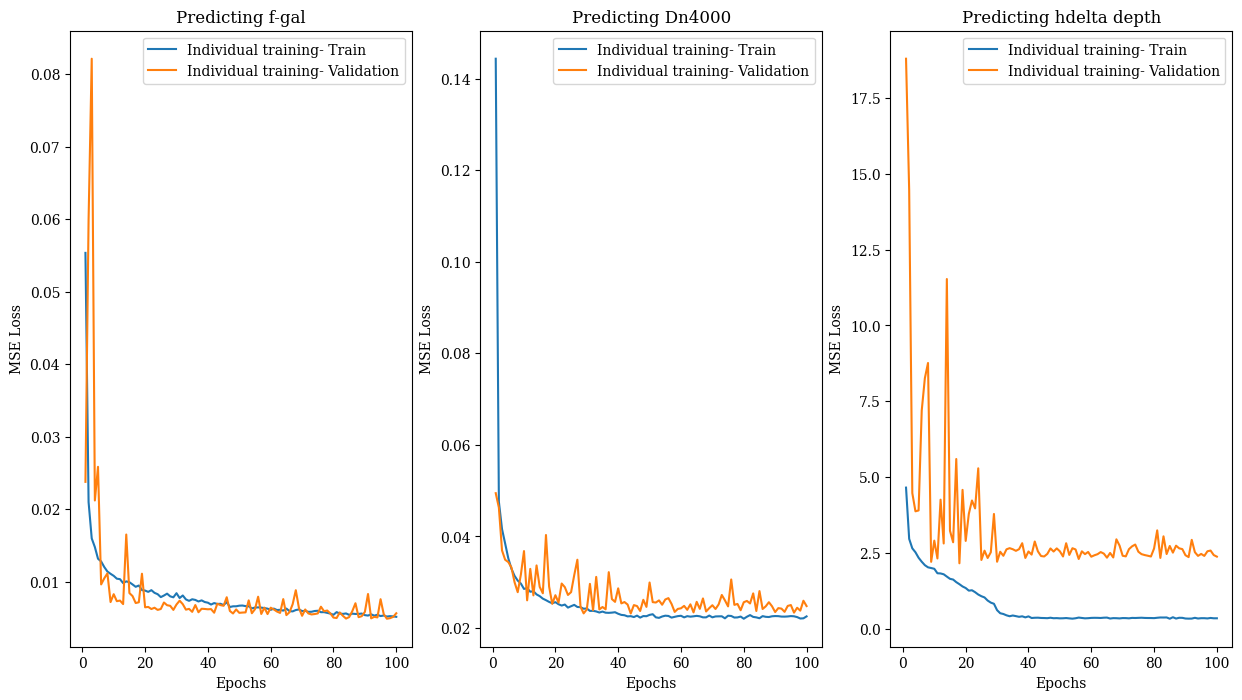

In [67]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M1_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M1_fgal_trainLossCurve, label='Individual training- Train')
ax[1].plot(epoch_array,M1_dn4_trainLossCurve, label='Individual training- Train')
ax[2].plot(epoch_array,M1_hdelta_trainLossCurve, label='Individual training- Train')

ax[0].plot(epoch_array,M1_fgal_validLossCurve, label='Individual training- Validation')
ax[1].plot(epoch_array,M1_dn4_validLossCurve, label='Individual training- Validation')
ax[2].plot(epoch_array,M1_hdelta_validLossCurve, label='Individual training- Validation')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()

## Individually trained but connected CNNs

- connect at start
- connect at fully connected section

### connected at the start

In [68]:
def trainModelResNet_sequential(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times
    train_loss_curve=[]
    valid_loss_curve=[]
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        for batch_data, batch_label, _, _,_ in traindataLoader:

            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item() # per batch

        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss+=validate_model_sequential(model, validdataLoader, lossCalculator) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


        train_loss_curve.append(epoch_train_loss)
        valid_loss_curve.append(epoch_valid_loss)

    return train_loss_curve, valid_loss_curve



def validate_model_sequential(model, validdataLoader, lossCalculator):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        for batch_data, batch_label, _ ,_,_ in validdataLoader:
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            lossValue+=lossCalculator(prediction, batch_label).item()

        lossValue /= len(validdataLoader)
    return lossValue

In [69]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class MASTERDATASET(torch.utils.data.Dataset):
  def __init__(self, flux, f_gal, dn4000, hdelta, type_hue):
    self.data=flux
    self.f_gal=f_gal
    self.dn4000=dn4000
    self.hdelta=hdelta
    self.hue=type_hue

    self.generateData()
    self.size=len(self.data)

  def generateData(self):
    self.tensordata=torch.Tensor(self.data)
    self.tensorf_gal=torch.Tensor(self.f_gal)
    self.tensor_dn4000=torch.Tensor(self.dn4000)
    self.tensor_hdelta=torch.Tensor(self.hdelta)
    self.tensor_Hue=torch.Tensor(self.hue)

  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorf_gal[index]
    data_dn400 =self.tensor_dn4000[index]
    data_hdelta =self.tensor_hdelta[index]
    data_hue = self.tensor_Hue[index]


    return data_point, data_f_gal, data_dn400, data_hdelta, data_hue

  def  __len__(self):
    return self.size

#create dataset
masterData=MASTERDATASET(firstDataset['flux'], firstDataset['f_gal'], firstDataset['dn4000'], firstDataset['hdelta'], firstDataset['gal_type_code'])


In [70]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class modifiedDataset(torch.utils.data.Dataset):
    def __init__(self, masterData, predicted_Data_f_gal, predicted_Data_dn4000, dataName):
        self.master=masterData
        self.predicted_Data_fgal=predicted_Data_f_gal
        self.predicted_Data_dn4000=predicted_Data_dn4000
        self.dataName=dataName

        self.generateData()
        self.size=len(self.master)

    def generateData(self):
        self.tensorPredicted_fgal=torch.Tensor(self.predicted_Data_fgal) if self.predicted_Data_fgal != None else None
        self.tensorPredicted_dn4000=torch.Tensor(self.predicted_Data_dn4000) if self.predicted_Data_dn4000 != None else None



    def __getitem__(self, index):
        if self.dataName=='f-gal':
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.unsqueeze(0)
            return data_flux, data_f_gal,data_dn4000 , data_hdelta, data_gal_type_code

        elif self.dataName=='dn4000':
            data_flux, data_f_gal , data_dn4000, data_hdelta ,data_gal_type_code= self.master[index]

            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_fgal[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)


            modified_batch_flux= torch.concat((data_flux, newChannel), dim=0)

            return modified_batch_flux ,data_dn4000, data_f_gal, data_hdelta,data_gal_type_code

        elif self.dataName=='hdelta':
            data_flux , data_dn4000, data_f_gal,data_hdelta,data_gal_type_code= self.master[index]

            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_dn4000[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.cat((data_flux, newChannel), dim=0) # add dn4000

            return modified_batch_flux, data_hdelta, data_f_gal , data_dn4000 , data_gal_type_code

        #return data_point, data_f_gal, data_dn400, data_hdelta, data_hue

    def  __len__(self):
        return self.size

In [71]:
f_galData=modifiedDataset(masterData, None, None, 'f-gal')

In [72]:
for i,h,j,k,l in f_galData:
    print(i,h,j,k,l)
    print(i.shape)
    break

tensor([[1.5542, 1.3226, 1.2657,  ..., 0.6589, 0.6553, 0.7390]]) tensor(0.2200) tensor(1.9056) tensor(-1.4662) tensor(4.)
torch.Size([1, 1890])


In [73]:
trainDataset_f_gal_V2, testDataset_f_gal_V2 = torch.utils.data.random_split(f_galData, [9000,1000])
trainDataset_f_gal_V2, validDataset_f_gal_V2 = torch.utils.data.random_split(trainDataset_f_gal_V2, [8800,200])

In [74]:
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100

train_data_loader_fgal_V2 = data.DataLoader(trainDataset_f_gal_V2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_fgal_V2 = data.DataLoader(validDataset_f_gal_V2, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_fgal_V2 = data.DataLoader(testDataset_f_gal_V2, batch_size=500, shuffle=False)

In [75]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_Version2=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)


optimiser= torch.optim.SGD(model_fgal_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_Version2.to(device)
loss= nn.MSELoss()
M2_fgal_trainLossCurve,M2_fgal_validLossCurve=trainModelResNet_sequential(model_fgal_Version2, train_data_loader_fgal_V2, valid_data_loader_fgal_V2, optimiser,
                            loss, 100, lrScheduler,verbose=True)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.044827740821479396 Valid loss: 0.02801735233515501 lr 0.001
Epoch No: 11 Train loss:  0.010935052946760235 Valid loss: 0.009663660079240799 lr 0.001
Epoch No: 21 Train loss:  0.009766449339010498 Valid loss: 0.007536740507930517 lr 0.001
Epoch No: 31 Train loss:  0.008625705139076506 Valid loss: 0.009986566845327616 lr 0.001
Epoch No: 41 Train loss:  0.007970133174041456 Valid loss: 0.007829176262021065 lr 0.001
Epoch No: 51 Train loss:  0.007493997022340244 Valid loss: 0.007176157319918275 lr 0.001
Epoch No: 61 Train loss:  0.007069006295536052 Valid loss: 0.0068091044668108225 lr 0.0001
Epoch No: 71 Train loss:  0.006973976281005889 Valid loss: 0.006550346035510302 lr 1e-05
Epoch No: 81 Train loss:  0.007002294451971962 Valid loss: 0.007421408547088504 lr 1.0000000000000002e-06
Epoch No: 91 Train loss:  0.006961775590157644 Valid loss: 0.008636331418529153 lr 1.0000000000000002e-07


In [76]:
# Then apply model, take predictions and concat to the traning set

# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_F_gal_predictions = data.DataLoader(trainDataset_f_gal_V2, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_fgal_Version2.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_F_gal_predictions:
        prediction = model_fgal_Version2(batch_data.to(device))
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_fgal_V2:
        prediction = model_fgal_Version2(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_fgal=torch.concat(prediction_train, dim=0)
prediction_valid_fgal=torch.concat(prediction_valid, dim=0)

In [77]:
dn4000_dataset_train=modifiedDataset(trainDataset_f_gal_V2, prediction_train_fgal, None, 'dn4000')
dn4000_dataset_valid=modifiedDataset(validDataset_f_gal_V2, prediction_valid_fgal, None, 'dn4000')

train_data_loader_dn4000_V2 = data.DataLoader(dn4000_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4000_V2 = data.DataLoader(dn4000_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [78]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4000_Version2=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


optimiser= torch.optim.SGD(model_dn4000_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_dn4000_Version2.to(device)
loss= nn.MSELoss()
M2_dn4_trainLossCurve,M2_dn4_validLossCurve=trainModelResNet_sequential(model_dn4000_Version2, train_data_loader_dn4000_V2, valid_data_loader_dn4000_V2, optimiser,
                            loss, 100, lrScheduler,verbose=True)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.14220856808295304 Valid loss: 0.04448327794671059 lr 0.001
Epoch No: 11 Train loss:  0.029220790369436145 Valid loss: 0.021550260484218597 lr 0.001
Epoch No: 21 Train loss:  0.025766082349317994 Valid loss: 0.019655401818454266 lr 0.001
Epoch No: 31 Train loss:  0.02427249340848489 Valid loss: 0.024554365314543247 lr 0.001
Epoch No: 41 Train loss:  0.022725385808470576 Valid loss: 0.020445577800273895 lr 0.001
Epoch No: 51 Train loss:  0.02185212054120546 Valid loss: 0.023511714302003384 lr 0.001
Epoch No: 61 Train loss:  0.021311486101793974 Valid loss: 0.018483387306332588 lr 0.001
Epoch No: 71 Train loss:  0.020620951306244188 Valid loss: 0.01584904035553336 lr 0.001
Epoch No: 81 Train loss:  0.01899710152806206 Valid loss: 0.016059081070125103 lr 0.001
Epoch No: 91 Train loss:  0.01888736434153874 Valid loss: 0.015670062974095345 lr 0.0001


In [79]:
# Then apply model, take predictions and concat to the traning set

# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_dn4000_predictions = data.DataLoader(dn4000_dataset_train, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_dn4000_Version2.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_dn4000_predictions:
        prediction = model_dn4000_Version2(batch_data.to(device))
        prediction_train.append(prediction)


    for batch_data,_,_,_,_ in valid_data_loader_dn4000_V2:
        prediction = model_dn4000_Version2(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_dn4000=torch.concat(prediction_train, dim=0)
prediction_valid_dn4000=torch.concat(prediction_valid, dim=0)

In [80]:
hdelta_dataset_train=modifiedDataset(dn4000_dataset_train,  None,prediction_train_dn4000, 'hdelta')
hdelta_dataset_valid=modifiedDataset(dn4000_dataset_valid,  None,prediction_valid_dn4000, 'hdelta')

train_data_loader_hdelta_V2 = data.DataLoader(hdelta_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta_V2 = data.DataLoader(hdelta_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [85]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_Version2=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)


optimiser= torch.optim.SGD(model_hdelta_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_hdelta_Version2.to(device)
loss= nn.MSELoss()
M2_hdelta_trainLossCurve,M2_hdelta_validLossCurve=trainModelResNet_sequential(model_hdelta_Version2, train_data_loader_hdelta_V2, valid_data_loader_hdelta_V2, optimiser,
                            loss, 100, lrScheduler,verbose=True)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  2.760717097195712 Valid loss: 1.8276689052581787 lr 0.001
Epoch No: 11 Train loss:  1.8913030193610625 Valid loss: 1.561939775943756 lr 0.001
Epoch No: 21 Train loss:  1.6662901788949966 Valid loss: 1.1989951729774475 lr 0.001
Epoch No: 31 Train loss:  1.4319286901842465 Valid loss: 1.1837801337242126 lr 0.001
Epoch No: 41 Train loss:  0.9703444031151858 Valid loss: 1.2233052849769592 lr 0.0001
Epoch No: 51 Train loss:  0.835332350703803 Valid loss: 1.2131478190422058 lr 1e-05
Epoch No: 61 Train loss:  0.8456777091730725 Valid loss: 1.2255759835243225 lr 1.0000000000000002e-06
Epoch No: 71 Train loss:  0.8583931395953351 Valid loss: 1.2228162586688995 lr 1.0000000000000002e-07
Epoch No: 81 Train loss:  0.8258630806749517 Valid loss: 1.2069548666477203 lr 1.0000000000000004e-08
Epoch No: 91 Train loss:  0.8066705912351608 Valid loss: 1.1814226508140564 lr 1.0000000000000004e-08


In [86]:
for i in train_data_loader_hdelta_V2:
    print(i[0])
    print(i[2])
    print(i[3])
    break

tensor([[[1.5240, 1.2083, 1.3710,  ..., 0.8298, 0.8720, 0.7289],
         [0.2707, 0.2707, 0.2707,  ..., 0.2707, 0.2707, 0.2707],
         [1.7170, 1.7170, 1.7170,  ..., 1.7170, 1.7170, 1.7170]],

        [[0.9504, 0.6602, 0.6744,  ..., 1.4684, 1.3931, 1.3767],
         [0.7663, 0.7663, 0.7663,  ..., 0.7663, 0.7663, 0.7663],
         [1.9157, 1.9157, 1.9157,  ..., 1.9157, 1.9157, 1.9157]],

        [[0.5882, 0.5749, 0.3061,  ..., 1.4137, 1.4711, 1.3919],
         [0.9293, 0.9293, 0.9293,  ..., 0.9293, 0.9293, 0.9293],
         [1.7154, 1.7154, 1.7154,  ..., 1.7154, 1.7154, 1.7154]],

        ...,

        [[0.8939, 0.8725, 0.5122,  ..., 1.2627, 1.3737, 1.2733],
         [0.8627, 0.8627, 0.8627,  ..., 0.8627, 0.8627, 0.8627],
         [1.5925, 1.5925, 1.5925,  ..., 1.5925, 1.5925, 1.5925]],

        [[1.7504, 1.3948, 1.4436,  ..., 0.7209, 0.7980, 0.5705],
         [0.1236, 0.1236, 0.1236,  ..., 0.1236, 0.1236, 0.1236],
         [1.6075, 1.6075, 1.6075,  ..., 1.6075, 1.6075, 1.6075]],

 

#### loss curves

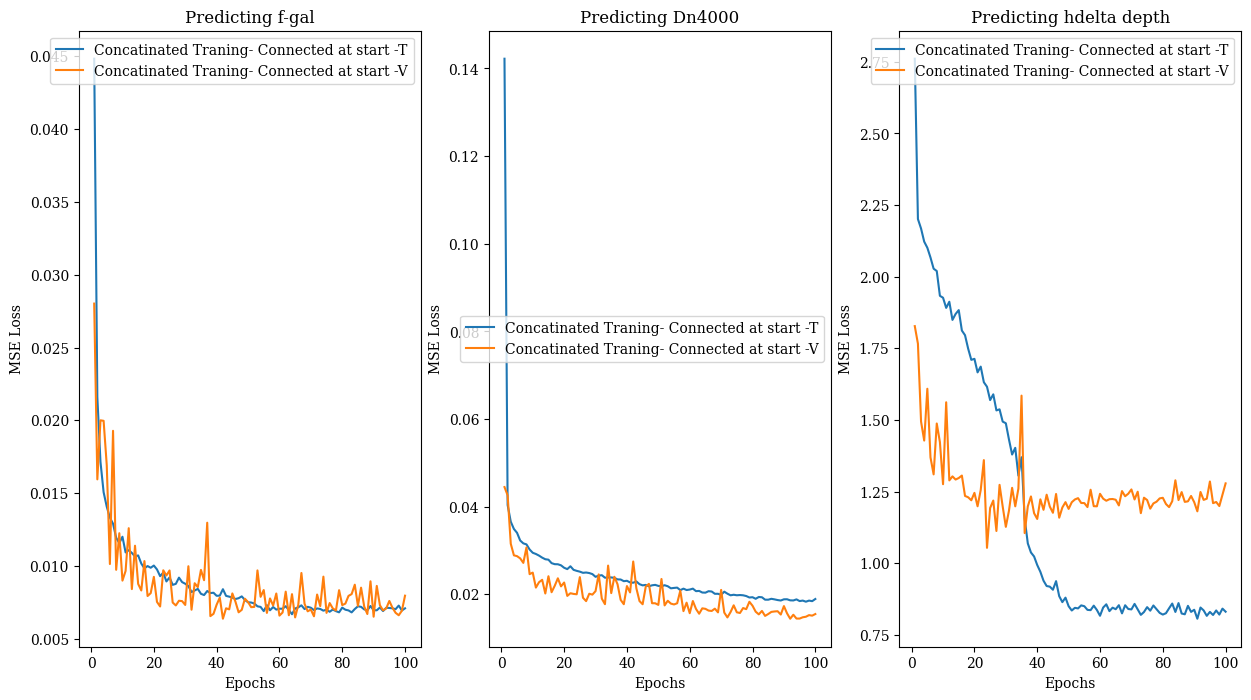

In [87]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M2_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M2_fgal_trainLossCurve, label='Concatinated Traning- Connected at start -T')
ax[1].plot(epoch_array,M2_dn4_trainLossCurve, label='Concatinated Traning- Connected at start -T')
ax[2].plot(epoch_array,M2_hdelta_trainLossCurve, label='Concatinated Traning- Connected at start -T')

ax[0].plot(epoch_array,M2_fgal_validLossCurve, label='Concatinated Traning- Connected at start -V')
ax[1].plot(epoch_array,M2_dn4_validLossCurve, label='Concatinated Traning- Connected at start -V')
ax[2].plot(epoch_array,M2_hdelta_validLossCurve, label='Concatinated Traning- Connected at start -V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()

### Individually trained but connected CNNs - connected at FC layer

In [88]:
def trainModelResNet_sequential_ConnectAtFC(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times
    train_loss_curve=[]
    valid_loss_curve=[]

    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        for batch_data, batch_label, _, _,_ in traindataLoader:


            batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
            if batch_data.shape[1] == 2:
                previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

            elif batch_data.shape[1] == 3:
                batch_fgal= batch_data[:,1,:][:,0].unsqueeze(1).to(device)
                batch_dn4000= batch_data[:,2,:][:,0].unsqueeze(1).to(device)
                previousPredictions=torch.concat((batch_fgal,batch_dn4000), dim=1)

            else:
                previousPredictions=None

            batch_label=batch_label.to(device)

            prediction=model(batch_flux, previousPredictions).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item() # per batch

        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss+=validate_model_sequential_ConnectAtFC(model, validdataLoader, lossCalculator) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


        train_loss_curve.append(epoch_train_loss)
        valid_loss_curve.append(epoch_valid_loss)

    return train_loss_curve, valid_loss_curve


def validate_model_sequential_ConnectAtFC(model, validdataLoader, lossCalculator):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        for batch_data, batch_label, _ ,_,_ in validdataLoader:

            batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
            if batch_data.shape[1] == 2:
                previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

            elif batch_data.shape[1] == 3:
                batch_fgal= batch_data[:,1,:][:,0].unsqueeze(1).to(device)
                batch_dn4000= batch_data[:,2,:][:,0].unsqueeze(1).to(device)
                previousPredictions=torch.concat((batch_fgal,batch_dn4000), dim=1)

            else:
                previousPredictions=None


            batch_label=batch_label.to(device)

            prediction=model(batch_flux, previousPredictions).squeeze()
            lossValue+=lossCalculator(prediction, batch_label).item()

        lossValue /= len(validdataLoader)
    return lossValue

In [89]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_Version3=fullResNetModel50(1,blockList, channelList, 1, False, stride, 0)

In [90]:
optimiser= torch.optim.SGD(model_fgal_Version3.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_Version3.to(device)
loss= nn.MSELoss()

M2P2_fgal_trainLossCurve,M2P2_fgal_validLossCurve=trainModelResNet_sequential_ConnectAtFC(model_fgal_Version3, train_data_loader_fgal_V2, valid_data_loader_fgal_V2, optimiser, loss,
                                        100,lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.06651256907392632 Valid loss: 0.03608794882893562 lr 0.001
Epoch No: 11 Train loss:  0.010971493940715763 Valid loss: 0.009244914632290602 lr 0.001
Epoch No: 21 Train loss:  0.009092718676071275 Valid loss: 0.010911724530160427 lr 0.001
Epoch No: 31 Train loss:  0.008457456200002609 Valid loss: 0.009114223532378674 lr 0.001
Epoch No: 41 Train loss:  0.007582499157764357 Valid loss: 0.007938217837363482 lr 0.001
Epoch No: 51 Train loss:  0.0070525443456559015 Valid loss: 0.007048552623018622 lr 0.0001
Epoch No: 61 Train loss:  0.007156273949129338 Valid loss: 0.007069169310852885 lr 1e-05
Epoch No: 71 Train loss:  0.006926838889591057 Valid loss: 0.0066013343166559935 lr 1.0000000000000002e-06
Epoch No: 81 Train loss:  0.007088473348200999 Valid loss: 0.006547263823449612 lr 1.0000000000000002e-06
Epoch No: 91 Train loss:  0.007283795975275676 Valid loss: 0.007829548558220267 lr 1.0000000000000002e-07


In [91]:
# Then apply model, take predictions and concat to the traning set
# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_F_gal_predictions = data.DataLoader(trainDataset_f_gal_V2, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_fgal_Version3.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_F_gal_predictions:
        prediction = model_fgal_Version3(batch_data.to(device))
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_fgal_V2:
        prediction = model_fgal_Version3(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_fgal=torch.concat(prediction_train, dim=0)
prediction_valid_fgal=torch.concat(prediction_valid, dim=0)

In [92]:
dn4000_dataset_train=modifiedDataset(trainDataset_f_gal_V2,  prediction_train_fgal,None, 'dn4000')
dn4000_dataset_valid=modifiedDataset(validDataset_f_gal_V2,  prediction_valid_fgal,None, 'dn4000')

train_data_loader_dn4000_V3 = data.DataLoader(dn4000_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4000_V3 = data.DataLoader(dn4000_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [93]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4000_Version3=fullResNetModel50(1,blockList, channelList, 1, False, stride, chainNumber=1)

In [94]:
optimiser= torch.optim.SGD(model_dn4000_Version3.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_dn4000_Version3.to(device)
loss= nn.MSELoss()

M2P2_dn4_trainLossCurve,M2P2_dn4_validLossCurve=trainModelResNet_sequential_ConnectAtFC(model_dn4000_Version3, train_data_loader_dn4000_V3, valid_data_loader_dn4000_V3, optimiser, loss,
                                        100,lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.1688990169120106 Valid loss: 0.05974870175123215 lr 0.001
Epoch No: 11 Train loss:  0.029337393373928287 Valid loss: 0.04305882193148136 lr 0.001
Epoch No: 21 Train loss:  0.025388446657664397 Valid loss: 0.033353416249156 lr 0.001
Epoch No: 31 Train loss:  0.02402399231849069 Valid loss: 0.025560070760548115 lr 0.001
Epoch No: 41 Train loss:  0.022550247169353745 Valid loss: 0.020667177625000477 lr 0.001
Epoch No: 51 Train loss:  0.021791452194818043 Valid loss: 0.020924287848174572 lr 0.001
Epoch No: 61 Train loss:  0.02104188677092845 Valid loss: 0.04276193305850029 lr 0.0001
Epoch No: 71 Train loss:  0.021126967287537726 Valid loss: 0.022264475002884865 lr 1e-05
Epoch No: 81 Train loss:  0.020678294098682024 Valid loss: 0.022961683571338654 lr 1.0000000000000002e-06
Epoch No: 91 Train loss:  0.020915196552364665 Valid loss: 0.022216474637389183 lr 1.0000000000000002e-07


In [95]:
# Then apply model, take predictions and concat to the traning set
# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_dn4000_predictions = data.DataLoader(dn4000_dataset_train, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_dn4000_Version3.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_dn4000_predictions:
        batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
        previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

        prediction = model_dn4000_Version3(batch_flux, previousPredictions)
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_dn4000_V3:
        batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
        previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

        prediction = model_dn4000_Version3(batch_flux, previousPredictions)
        prediction_valid.append(prediction)


prediction_train_dn4000=torch.concat(prediction_train, dim=0)
prediction_valid_dn4000=torch.concat(prediction_valid, dim=0)

In [96]:
hdelta_dataset_train=modifiedDataset(dn4000_dataset_train, None ,prediction_train_dn4000, 'hdelta')
hdelta_dataset_valid=modifiedDataset(dn4000_dataset_valid, None ,prediction_valid_dn4000, 'hdelta')

train_data_loader_hdelta_V3 = data.DataLoader(hdelta_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta_V3 = data.DataLoader(hdelta_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [97]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_Version3=fullResNetModel50(1,blockList, channelList, 1, False, stride, chainNumber=2)

In [98]:
optimiser= torch.optim.SGD(model_hdelta_Version3.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_hdelta_Version3.to(device)
loss= nn.MSELoss()

M2P2_hdelta_trainLossCurve,M2P2_hdelta_validLossCurve=trainModelResNet_sequential_ConnectAtFC(model_hdelta_Version3, train_data_loader_hdelta_V3, valid_data_loader_hdelta_V3, optimiser, loss,
                                        100,lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  4.711969334428961 Valid loss: 26.611742973327637 lr 0.001
Epoch No: 11 Train loss:  1.8037931220097976 Valid loss: 5.1424620151519775 lr 0.001
Epoch No: 21 Train loss:  1.0502717062830924 Valid loss: 1.983567237854004 lr 0.0001
Epoch No: 31 Train loss:  0.7893508714708415 Valid loss: 2.1196570992469788 lr 1e-05
Epoch No: 41 Train loss:  0.7647715544158762 Valid loss: 2.1193659901618958 lr 1.0000000000000002e-06
Epoch No: 51 Train loss:  0.7663415403528647 Valid loss: 2.256226062774658 lr 1.0000000000000002e-06
Epoch No: 61 Train loss:  0.7463009364225648 Valid loss: 2.212416172027588 lr 1.0000000000000002e-07
Epoch No: 71 Train loss:  0.7915011259642515 Valid loss: 2.1889954209327698 lr 1.0000000000000004e-08
Epoch No: 81 Train loss:  0.7616574311120944 Valid loss: 2.2318623661994934 lr 1.0000000000000004e-08
Epoch No: 91 Train loss:  0.7534228323535486 Valid loss: 2.2103756070137024 lr 1.0000000000000004e-08


#### loss curves

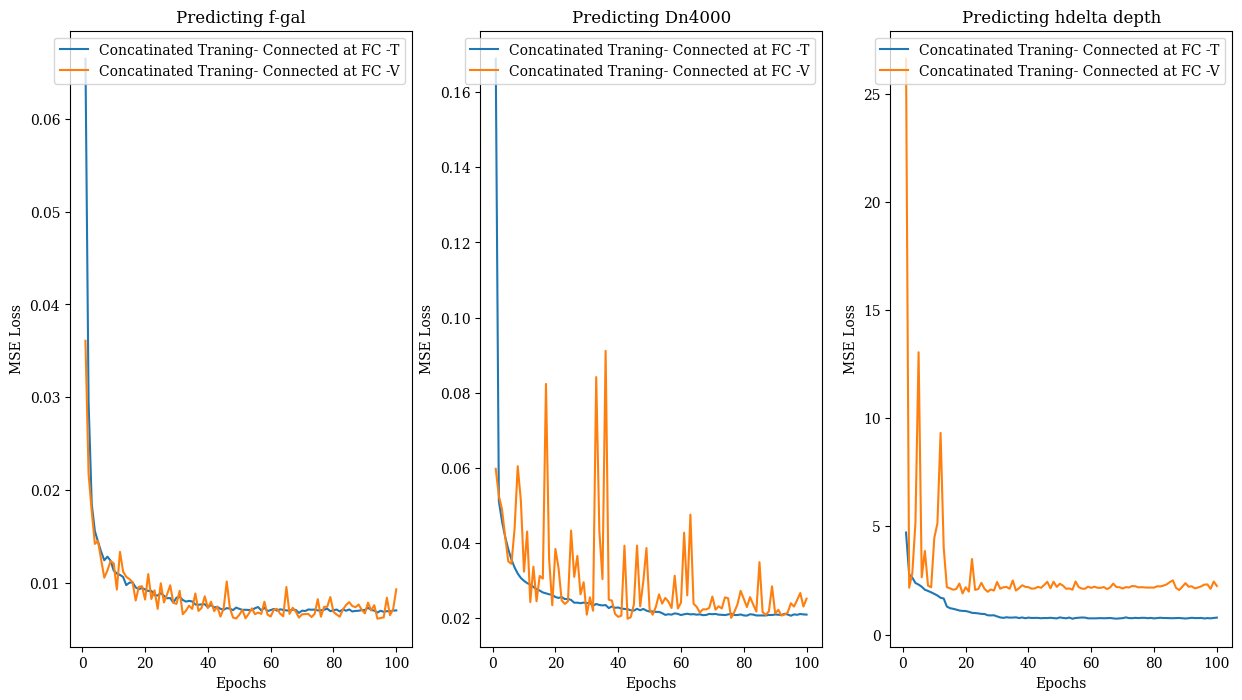

In [99]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M2P2_fgal_trainLossCurve)+1,1)


ax[0].plot(epoch_array,M2P2_fgal_trainLossCurve, label='Concatinated Traning- Connected at FC -T')
ax[1].plot(epoch_array,M2P2_dn4_trainLossCurve, label='Concatinated Traning- Connected at FC -T')
ax[2].plot(epoch_array,M2P2_hdelta_trainLossCurve, label='Concatinated Traning- Connected at FC -T')

ax[0].plot(epoch_array,M2P2_fgal_validLossCurve, label='Concatinated Traning- Connected at FC -V')
ax[1].plot(epoch_array,M2P2_dn4_validLossCurve, label='Concatinated Traning- Connected at FC -V')
ax[2].plot(epoch_array,M2P2_hdelta_validLossCurve, label='Concatinated Traning- Connected at FC -V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


## Simultaneous traning

In [100]:
# train 3 models at the same time
def regressorTrainLoop(model, batch_data, batch_label,lossCalculator, optimiser):

    model.train()

    prediction=model(batch_data).squeeze()
    loss= lossCalculator(prediction, batch_label)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    epoch_train_loss = loss.item() # per batch

    return epoch_train_loss, prediction


def regressorValidationLoop(model, batch_data, batch_label,lossCalculator ):
    model.eval()
    with torch.no_grad():
        prediction=model(batch_data).squeeze()
        lossValue=lossCalculator(prediction, batch_label).item()


    return lossValue, prediction

def epochLoop(epochs, modelF_gal, model_dn4000, model_hdelta , traindataLoader, validdataLoader, loss_f_gal, loss_dn4, loss_hdel, optimiser_f_gal, optimiser_dn4, optimiser_hdel,scheduler_f_gal, scheduler_dn4, scheduler_hdel):
    #train on traning set epochs times
    M3_fgal_trainLossCurve=[]
    M3_fgal_validLossCurve=[]
    M3_dn4_trainLossCurve=[]
    M3_dn4_validLossCurve=[]
    M3_hdelta_trainLossCurve=[]
    M3_hdelta_validLossCurve=[]
    for epoch in tqdm(range(1, epochs+1)):
        epoch_train_loss_F_gal=0
        epoch_valid_loss_F_gal=0

        epoch_train_loss_dn4=0
        epoch_valid_loss_dn4=0

        epoch_train_loss_hdel=0
        epoch_valid_loss_hdel=0


        for batch_flux, batch_f_gal, _ , batch_dn4, batch_hdel  in traindataLoader:

            batch_flux=batch_flux.unsqueeze(1)
            batch_flux=batch_flux.to(device)
            batch_f_gal=batch_f_gal.to(device)
            batch_dn4 =batch_dn4.to(device)
            batch_hdel=batch_hdel.to(device)

            temp1, f_galPrediction =regressorTrainLoop(modelF_gal , batch_flux, batch_f_gal, loss_f_gal, optimiser_f_gal)

            # edit the batch_flux to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux = torch.cat((batch_flux, newChannel), dim=1)  # contains new channel per input with predicted f_gal

            temp2, dn4Prediction= regressorTrainLoop(model_dn4000, modified_batch_flux, batch_dn4, loss_dn4, optimiser_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_2 = torch.cat((modified_batch_flux, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            temp3, _ = regressorTrainLoop(model_hdelta, modified_batch_flux_2, batch_hdel, loss_hdel, optimiser_hdel)

            epoch_train_loss_F_gal+=temp1
            epoch_train_loss_dn4+=temp2
            epoch_train_loss_hdel+=temp3



        for batch_flux_V, batch_f_gal_V, _ , batch_dn4_V, batch_hdel_V in validdataLoader:

            batch_flux_V=batch_flux_V.unsqueeze(1)
            batch_flux_V=batch_flux_V.to(device)
            batch_f_gal_V=batch_f_gal_V.to(device)
            batch_dn4_V=batch_dn4_V.to(device)
            batch_hdel_V=batch_hdel_V.to(device)


            temp1, f_galPrediction=regressorValidationLoop(modelF_gal,batch_flux_V, batch_f_gal_V, loss_f_gal)

            # edit the batch_flux_V to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V = torch.cat((batch_flux_V, newChannel), dim=1) # contains new channel per input with predicted f_gal

            temp2, dn4Prediction=regressorValidationLoop(model_dn4000,modified_batch_flux_V, batch_dn4_V, loss_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V_2 = torch.cat((modified_batch_flux_V, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            temp3, _ = regressorValidationLoop(model_hdelta, modified_batch_flux_V_2, batch_hdel_V, loss_hdel)

            epoch_valid_loss_F_gal+=temp1
            epoch_valid_loss_dn4+=temp2
            epoch_valid_loss_hdel+=temp3



        epoch_train_loss_F_gal/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_F_gal/=len(validdataLoader) # average over number of batches

        epoch_train_loss_dn4/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_dn4/=len(validdataLoader) # average over number of batches

        epoch_train_loss_hdel/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_hdel/=len(validdataLoader) # average over number of batches


        scheduler_f_gal.step(epoch_valid_loss_F_gal)
        scheduler_dn4.step(epoch_valid_loss_dn4)
        scheduler_hdel.step(epoch_valid_loss_hdel)


        M3_fgal_trainLossCurve.append(epoch_train_loss_F_gal)
        M3_fgal_validLossCurve.append(epoch_valid_loss_F_gal)
        M3_dn4_trainLossCurve.append(epoch_train_loss_dn4)
        M3_dn4_validLossCurve.append(epoch_valid_loss_dn4)
        M3_hdelta_trainLossCurve.append(epoch_train_loss_hdel)
        M3_hdelta_validLossCurve.append(epoch_valid_loss_hdel)


        epoch_train_loss_F_gal=round(epoch_train_loss_F_gal, 10)
        epoch_valid_loss_F_gal=round(epoch_valid_loss_F_gal, 10)
        epoch_train_loss_dn4= round(epoch_train_loss_dn4, 10)
        epoch_valid_loss_dn4= round(epoch_valid_loss_dn4, 10)
        epoch_train_loss_hdel=round(epoch_train_loss_hdel, 10)
        epoch_valid_loss_hdel=round(epoch_valid_loss_hdel, 10)


        # Printing accuracy values ----------
        if epochs > 21:
            if epoch % 5 == 0:
                print('--------------Epoch Number: ', epoch,'--------------')
                print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
                print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
                print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])
        else:
            print('---------------Epoch Number: ', epoch,'--------------')
            print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
            print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
            print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])


    return M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve

In [101]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)
model_dn4_simul=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_hdel= torch.optim.SGD(model_hdel_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul.to(device)
model_dn4_simul.to(device)
model_hdel_simul.to(device)
epochs=100

M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve=epochLoop(epochs, model_fgal_simul, model_dn4_simul, model_hdel_simul,
          train_data_loader, valid_data_loader,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/100 [00:00<?, ?it/s]

--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.0134363777 Validation Loss: 0.0187777085 lr: 0.001
Model-Dn4000| Train loss: 0.0360864875 Validation Loss: 0.0597117078 lr: 0.001
Model-Hdelta| Train loss: 2.2227437924 Validation Loss: 4.2739027739 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0115969642 Validation Loss: 0.0187850804 lr: 0.001
Model-Dn4000| Train loss: 0.0301886884 Validation Loss: 0.0415259488 lr: 0.001
Model-Hdelta| Train loss: 1.786271723 Validation Loss: 2.2300379276 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0101402317 Validation Loss: 0.0165634714 lr: 0.001
Model-Dn4000| Train loss: 0.0272944527 Validation Loss: 0.0314699132 lr: 0.001
Model-Hdelta| Train loss: 1.5407455837 Validation Loss: 1.8072507381 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0092345598 Validation Loss: 0.0111679286 lr: 0.001
Model-Dn4000| Train loss

#### loss curves

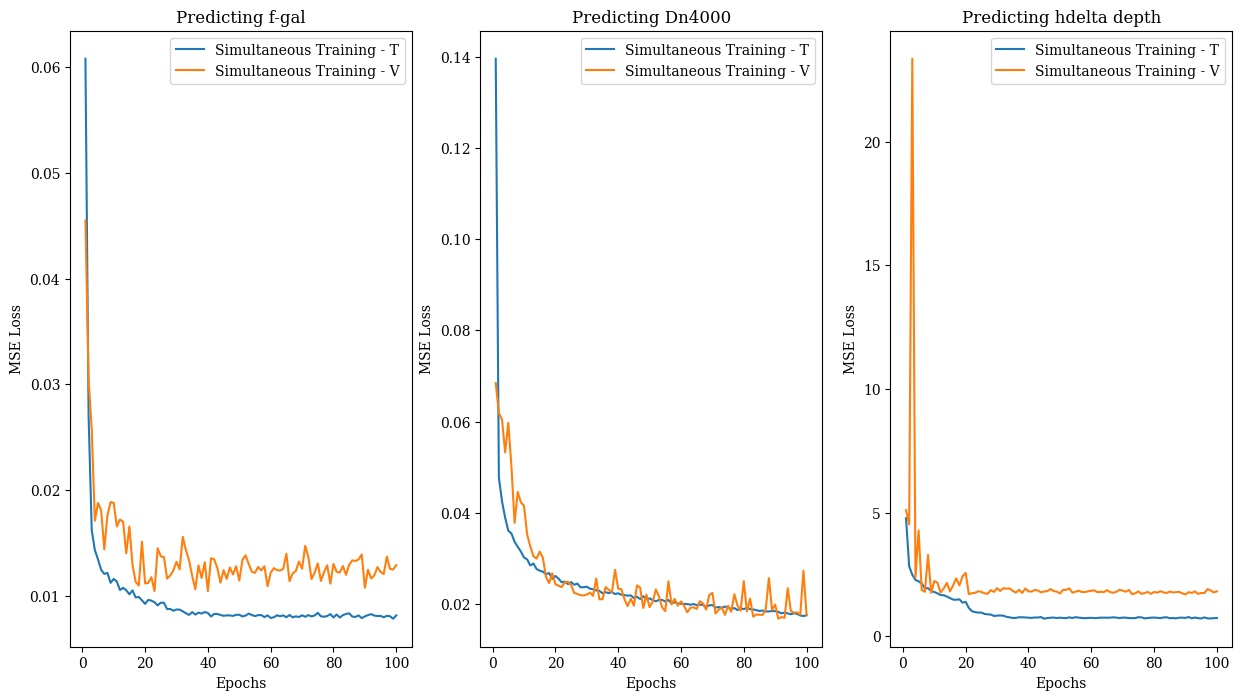

In [103]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


## Combined Loss Graphs

- f-gal for each method should more or less be the same, it is the same method of input data just small variation in intial randomness that should disappear after enough epochs

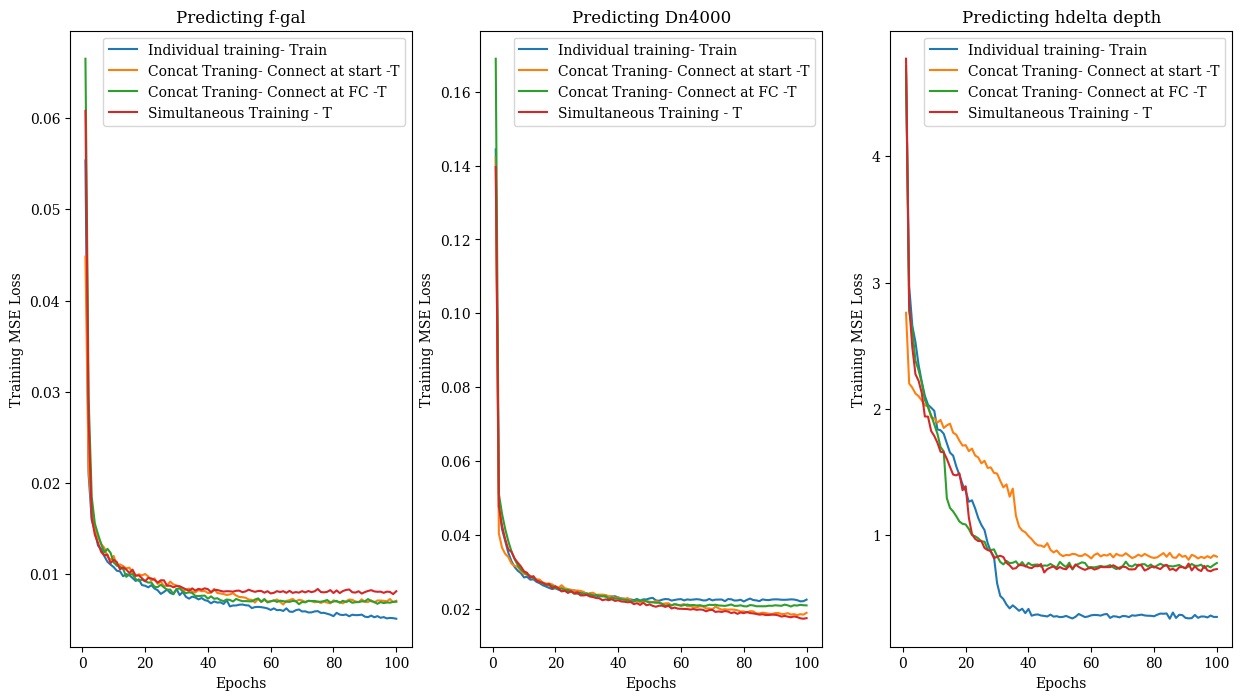

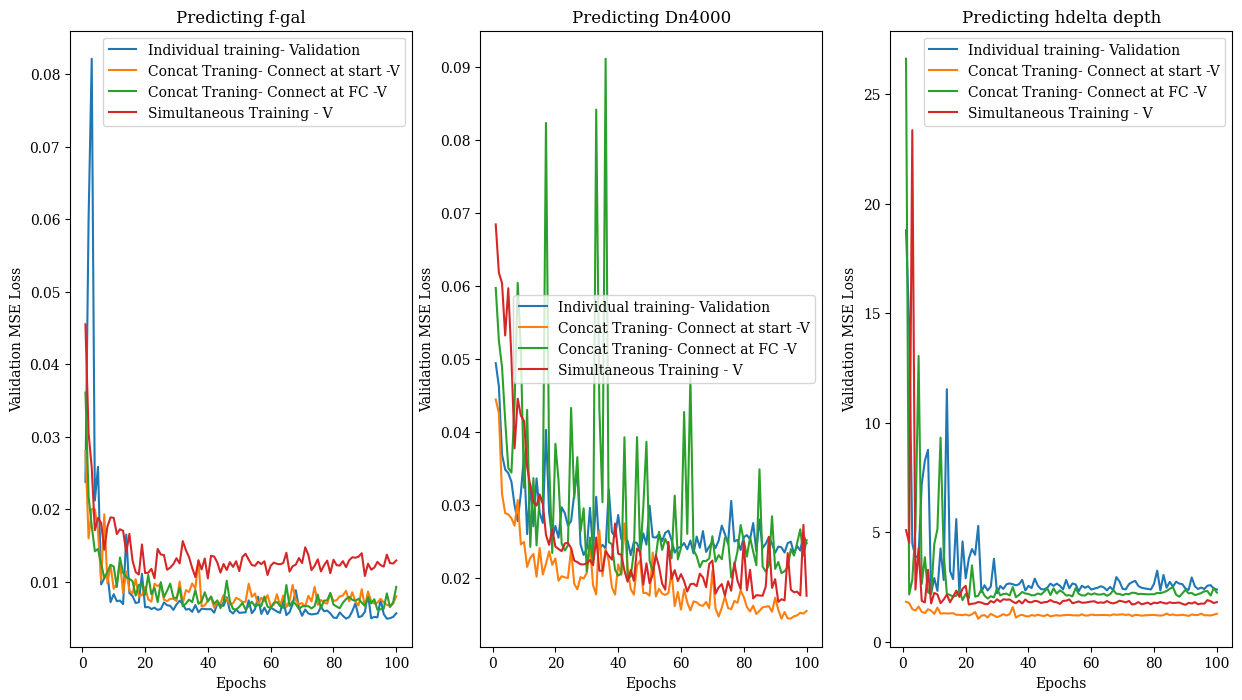

In [104]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig1, ax1=plt.subplots(figsize=(15,8), ncols=3)

epoch_array=np.arange(1,len(M1_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M1_fgal_trainLossCurve, label='Individual training- Train')
ax[1].plot(epoch_array,M1_dn4_trainLossCurve, label='Individual training- Train')
ax[2].plot(epoch_array,M1_hdelta_trainLossCurve, label='Individual training- Train')

ax1[0].plot(epoch_array,M1_fgal_validLossCurve, label='Individual training- Validation')
ax1[1].plot(epoch_array,M1_dn4_validLossCurve, label='Individual training- Validation')
ax1[2].plot(epoch_array,M1_hdelta_validLossCurve, label='Individual training- Validation')


ax[0].plot(epoch_array,M2_fgal_trainLossCurve, label='Concat Traning- Connect at start -T')
ax[1].plot(epoch_array,M2_dn4_trainLossCurve, label='Concat Traning- Connect at start -T')
ax[2].plot(epoch_array,M2_hdelta_trainLossCurve, label='Concat Traning- Connect at start -T')

ax1[0].plot(epoch_array,M2_fgal_validLossCurve, label='Concat Traning- Connect at start -V')
ax1[1].plot(epoch_array,M2_dn4_validLossCurve, label='Concat Traning- Connect at start -V')
ax1[2].plot(epoch_array,M2_hdelta_validLossCurve, label='Concat Traning- Connect at start -V')


ax[0].plot(epoch_array,M2P2_fgal_trainLossCurve, label='Concat Traning- Connect at FC -T')
ax[1].plot(epoch_array,M2P2_dn4_trainLossCurve, label='Concat Traning- Connect at FC -T')
ax[2].plot(epoch_array,M2P2_hdelta_trainLossCurve, label='Concat Traning- Connect at FC -T')

ax1[0].plot(epoch_array,M2P2_fgal_validLossCurve, label='Concat Traning- Connect at FC -V')
ax1[1].plot(epoch_array,M2P2_dn4_validLossCurve, label='Concat Traning- Connect at FC -V')
ax1[2].plot(epoch_array,M2P2_hdelta_validLossCurve, label='Concat Traning- Connect at FC -V')


ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax1[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax1[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax1[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

#---------------labels
ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax1[0].set_title('Predicting f-gal')
ax1[1].set_title('Predicting Dn4000')
ax1[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax1[0].set_xlabel('Epochs')
ax1[1].set_xlabel('Epochs')
ax1[2].set_xlabel('Epochs')

ax[0].set_ylabel('Training MSE Loss')
ax[1].set_ylabel('Training MSE Loss')
ax[2].set_ylabel('Training MSE Loss')

ax1[0].set_ylabel('Validation MSE Loss')
ax1[1].set_ylabel('Validation MSE Loss')
ax1[2].set_ylabel('Validation MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax1[0].legend()
ax1[1].legend()
ax1[2].legend()

## Graphing Prediction vs Truth

- indiv  [DONE]
    - input required: just flux array

        - model_fgal_indv
        - model_dn4_indv
        - model_hdelta_indv


- Concat- at start [DONE]
    - input required: just flux array + prediction from previous models as new channel

        - model_fgal_Version2
        - model_dn4000_Version2
        - model_hdelta_Version2

- concat - at fc
    -  input required: just flux array + prediction from previous models as new channel
        - model_fgal_Version3
        - model_dn4000_Version3
        - model_hdelta_Version3


-  Simul
    -  input required: just flux array + prediction from previous models as new channel
        - model_fgal_simul
        - model_dn4_simul
        - model_hdel_simul

### graphing functions




In [200]:
#graph
def dataFor_graphPredictionTruth(model, train_data_loader, valid_data_loder, predictingWhat):
    # returns model predictions on training and validation data
    model.eval()
    predict_train=np.array([])
    truth_train=np.array([])
    diff_train=np.array([])
    hue_train=np.array([])

    predict_val=np.array([])
    truth_val=np.array([])
    diff_val=np.array([])
    hue_val=np.array([])

    for flux, f_gal, dn4000, hdelta, gal_type_code in train_data_loader:
        with torch.no_grad():
            trial_batch_p=flux.to(device)
            trial_batch_hue=gal_type_code

            if predictingWhat == 'f-gal':
                trial_batch_t=f_gal.to(device)
            elif  predictingWhat == 'dn4000' :
                trial_batch_t=dn4000.to(device)
            elif predictingWhat == 'hdelta':
                trial_batch_t=hdelta.to(device)


            if trial_batch_p.shape[1] not in [1,2,3]:
                trial_batch_p=trial_batch_p.unsqueeze(1)

            predict_train=np.append(predict_train, model(trial_batch_p).cpu().squeeze().detach().numpy())
        truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())
        hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

    diff_train=np.append(diff_train,truth_train-predict_train)


    for flux, f_gal, dn4000, hdelta, gal_type_code in valid_data_loder:
        with torch.no_grad():
            trial_batch_p=flux.to(device)
            trial_batch_hue=gal_type_code

            if predictingWhat == 'f-gal':
                trial_batch_t=f_gal.to(device)
            elif  predictingWhat == 'dn4000' :
                trial_batch_t=dn4000.to(device)
            elif predictingWhat == 'hdelta':
                trial_batch_t=hdelta.to(device)

            if trial_batch_p.shape[1] not in [1,2,3]:
                trial_batch_p=trial_batch_p.unsqueeze(1)

            predict_val=np.append(predict_val,model(trial_batch_p).cpu().squeeze().detach().numpy())
        truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())
        hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())

    diff_val=truth_val-predict_val


    return [predict_train,truth_train,diff_train, hue_train], [predict_val,truth_val,diff_val,hue_val]

In [201]:
def graphPredictionTruth(predict_train, truth_train, diff_train, hue_train,predict_val, truth_val, diff_val, hue_val, attempt,ax, hueBool, le):
    # uses prediction from dataFor_graphPredictionTruth_alex to plot graphs
    ax[0].set_yticklabels([])
    ax[0].set_xticklabels([])
    ax[1].set_yticklabels([])
    ax[1].set_xticklabels([])

    frame2=fig.add_axes((.05,.25,.45,.75)) # splits graphs into 4 graphs with bottom 2 graphs being smaller
    frame1=fig.add_axes((.05,.01,.45,.25))

    frame4=fig.add_axes((.54,.25,.45,.75))
    frame3=fig.add_axes((.54,.01,.45,.25))


    # creates 2D array of training results and validation results
    t = np.array(list(zip(predict_train, truth_train, diff_train, hue_train)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])
    if hueBool == False:
        # doesn't colour based on gal_type
        frame2.scatter(x=t['truth'], y=t['predict'], c='blue', alpha=0.2, label='Data')
        frame1.scatter(x=t['truth'], y=t['diff'], c='blue', alpha=0.2)
    else:
        # colours based on gal type
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame2, alpha=0.2, hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df, x='truth', y='diff',hue='gal_type', ax=frame1, alpha=0.2,hue_order=['SB', 'SF', 'green','red', 'PSB'])


    minTruth=min(truth_train)
    maxTruth=max(truth_train)
    frame2.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange',label='Truth=Prediction')
    frame1.plot([minTruth,maxTruth],[0,0], c='orange')
    #frame1.set_ylim(-0.099,0.099)

    frame1.set_xlabel('True', size=20)
    frame2.set_ylabel('Predicted ', size=20)
    frame1.set_ylabel('Difference', size=16)
    frame2.set_title(attempt+' Train Set', fontsize=34)

    t = np.array(list(zip(predict_val, truth_val, diff_val, hue_val)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])

    if hueBool==False:
        frame4.scatter(x=t['truth'], y=t['predict'], label='Data')
        frame3.scatter(x=t['truth'], y=t['diff'], c='blue' )

    else:
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame4,hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df,x='truth', y='diff', hue='gal_type', ax=frame3,hue_order=['SB', 'SF', 'green','red', 'PSB'])


    minTruth=min(truth_val)
    maxTruth=max(truth_val)
    frame4.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange', label='Truth=Prediction')
    frame3.plot([minTruth,maxTruth], [0,0], c='orange')
    #frame3.set_ylim(-0.099,0.099)

    frame3.set_xlabel('True', size=20)
    frame4.set_title(attempt+' Validation Set', fontsize=34)

#----------------------Labels and axis-----------------------------------------
    frame3.tick_params(axis='both', which='major', labelsize=14)
    frame3.tick_params(axis='both', which='minor', labelsize=12)
    frame4.tick_params(axis='both', which='major', labelsize=14)
    frame4.tick_params(axis='both', which='minor', labelsize=12)
    frame2.tick_params(axis='both', which='major', labelsize=14)
    frame2.tick_params(axis='both', which='minor', labelsize=12)
    frame1.tick_params(axis='both', which='major', labelsize=14)
    frame1.tick_params(axis='both', which='minor', labelsize=12)

    frame1.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame1.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame2.yaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame4.yaxis.set_minor_locator(AutoMinorLocator(4))

    frame3.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame4.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame2.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame1.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    _=frame4.legend(prop={'size':13})
    _=frame2.legend(prop={'size':13})

    if hueBool:
        frame1.get_legend().set_visible(False)
        frame3.get_legend().set_visible(False)
    frame3.set_ylabel('')
    frame4.set_ylabel('')

In [202]:
def graphGalTypeHist(diff, galType, ax,le):
    t = np.array(list(zip(diff, galType)), dtype = [('diff', float), ('gal_type', int)])
    df = pd.DataFrame.from_records(t)
    df['gal_type']=le.inverse_transform(df['gal_type'])

    plot=sns.kdeplot(data=df, x='diff', hue='gal_type', ax=ax, fill=False,
                hue_order=['SB', 'SF', 'green','red', 'PSB'], legend=True)


    #----Labels-------------------
    XaxisLimit= 0.1 #@param {type:"slider", min:0, max:0.15, step:0.01}
    axisLabelSize=20 #@param {type:"slider", min:10, max:25, step:1}
    ticklabelSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendTitleFontSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendSize=13 #@param {type:"slider", min:10, max:25, step:1}

    ax.set_xlim(-1*XaxisLimit, XaxisLimit)
    ax.set_ylabel('Density', size=axisLabelSize)
    ax.set_xlabel('Difference', size=axisLabelSize)
    ax.tick_params(axis='both', which='major', labelsize=ticklabelSize)
    sns.move_legend(plot, title='Galaxy Types', loc='upper right', title_fontsize=legendTitleFontSize,prop={'size':legendSize})


In [217]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class graphDatasetmodifier(torch.utils.data.Dataset):
    def __init__(self, masterData, predicted_Data_f_gal, predicted_Data_dn4000):
        self.master=masterData
        self.predicted_Data_fgal=predicted_Data_f_gal
        self.predicted_Data_dn4000=predicted_Data_dn4000

        self.generateData()
        self.size=len(self.master)

    def generateData(self):
        self.tensorPredicted_fgal=torch.Tensor(self.predicted_Data_fgal) if self.predicted_Data_fgal is not None else None
        self.tensorPredicted_dn4000=torch.Tensor(self.predicted_Data_dn4000) if self.predicted_Data_dn4000 is not None else None



    def __getitem__(self, index):
        if self.predicted_Data_fgal is None and self.predicted_Data_dn4000 is None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            return data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code

        elif self.predicted_Data_fgal is not None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_fgal[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.concat((data_flux.unsqueeze(0).cpu(), newChannel.cpu()), dim=0)

            return modified_batch_flux ,data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code


        elif self.predicted_Data_dn4000 is not None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_dn4000[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.concat((data_flux.cpu(), newChannel.cpu()), dim=0)
            return modified_batch_flux ,data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code
    def  __len__(self):
        return self.size

### calling graph functions

#### indiv models

In [219]:
# data for indiv models
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100


masterData=MASTERDATASET(firstDataset['flux'], firstDataset['f_gal'], firstDataset['dn4000'], firstDataset['hdelta'], firstDataset['gal_type_code'])

graphTrainDataset, graphValidDataset, graphTestDataset = torch.utils.data.random_split(masterData, [8800,200,1000])

graphTrain_data_loader = data.DataLoader(graphTrainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader = data.DataLoader(graphValidDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
graphTest_data_loader = data.DataLoader(graphTestDataset, batch_size=500, shuffle=False)



In [220]:
# graph data for indiv
trainGraphdata_1_fgal,validGraphdata_1_fgal= dataFor_graphPredictionTruth(model_fgal_indv, graphTrain_data_loader, graphValid_data_loader, 'f-gal')
trainGraphdata_1_dn4,validGraphdata_1_dn4= dataFor_graphPredictionTruth(model_dn4_indv, graphTrain_data_loader, graphValid_data_loader, 'dn4000')
trainGraphdata_1_hdel,validGraphdata_1_hdel= dataFor_graphPredictionTruth(model_hdelta_indv, graphTrain_data_loader, graphValid_data_loader, 'hdelta')

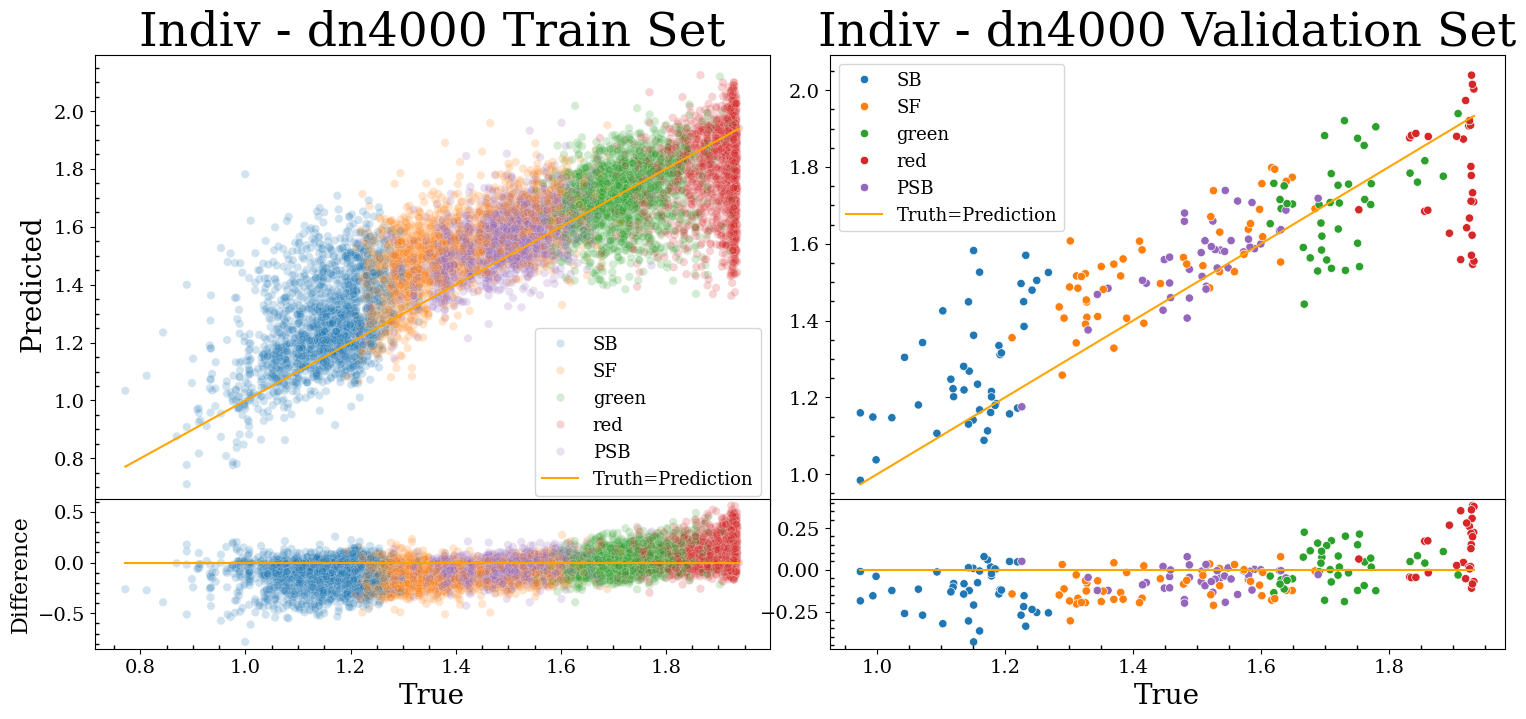

In [225]:
# plot for indiv models
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
#graphPredictionTruth(*trainGraphdata_1_fgal,*validGraphdata_1_fgal, 'Indiv - fgal',ax, True, le)
graphPredictionTruth(*trainGraphdata_1_dn4,*validGraphdata_1_dn4, 'Indiv - dn4000',ax, True, le)
#graphPredictionTruth(*trainGraphdata_1_hdel,*validGraphdata_1_hdel, 'Indiv - Hdelta',ax, True, le)

#### Concat Model- At start

In [222]:
# make predictions for graph
trainGraphdata_2_fgal,validGraphdata_2_fgal= dataFor_graphPredictionTruth(model_fgal_Version2, graphTrain_data_loader,
                                                                          graphValid_data_loader, 'f-gal')

# use predictions to make combine flux and predicted f-gal to the data needed for next model
graphTrain_dataset_2=graphDatasetmodifier(graphTrainDataset, trainGraphdata_2_fgal[0], None)
graphValid_dataset_2=graphDatasetmodifier(graphValidDataset, validGraphdata_2_fgal[0], None)

graphTrain_data_loader_2 = data.DataLoader(graphTrain_dataset_2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_2 = data.DataLoader(graphValid_dataset_2, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_2_dn4,validGraphdata_2_dn4= dataFor_graphPredictionTruth(model_dn4000_Version2, graphTrain_data_loader_2,
                                                                          graphValid_data_loader_2, 'dn4000')

# use predictions to make combine flux + predicted f-gal with predicted dn4000 to the data needed for next model
graphTrain_dataset_3=graphDatasetmodifier(graphTrain_dataset_2, None, trainGraphdata_2_dn4[0])
graphValid_dataset_3=graphDatasetmodifier(graphValid_dataset_2, None, validGraphdata_2_dn4[0])

graphTrain_data_loader_3 = data.DataLoader(graphTrain_dataset_3, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_3 = data.DataLoader(graphValid_dataset_3, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_2_hdel,validGraphdata_2_hdel= dataFor_graphPredictionTruth(model_hdelta_Version2, graphTrain_data_loader_3,
                                                                          graphValid_data_loader_3, 'hdelta')



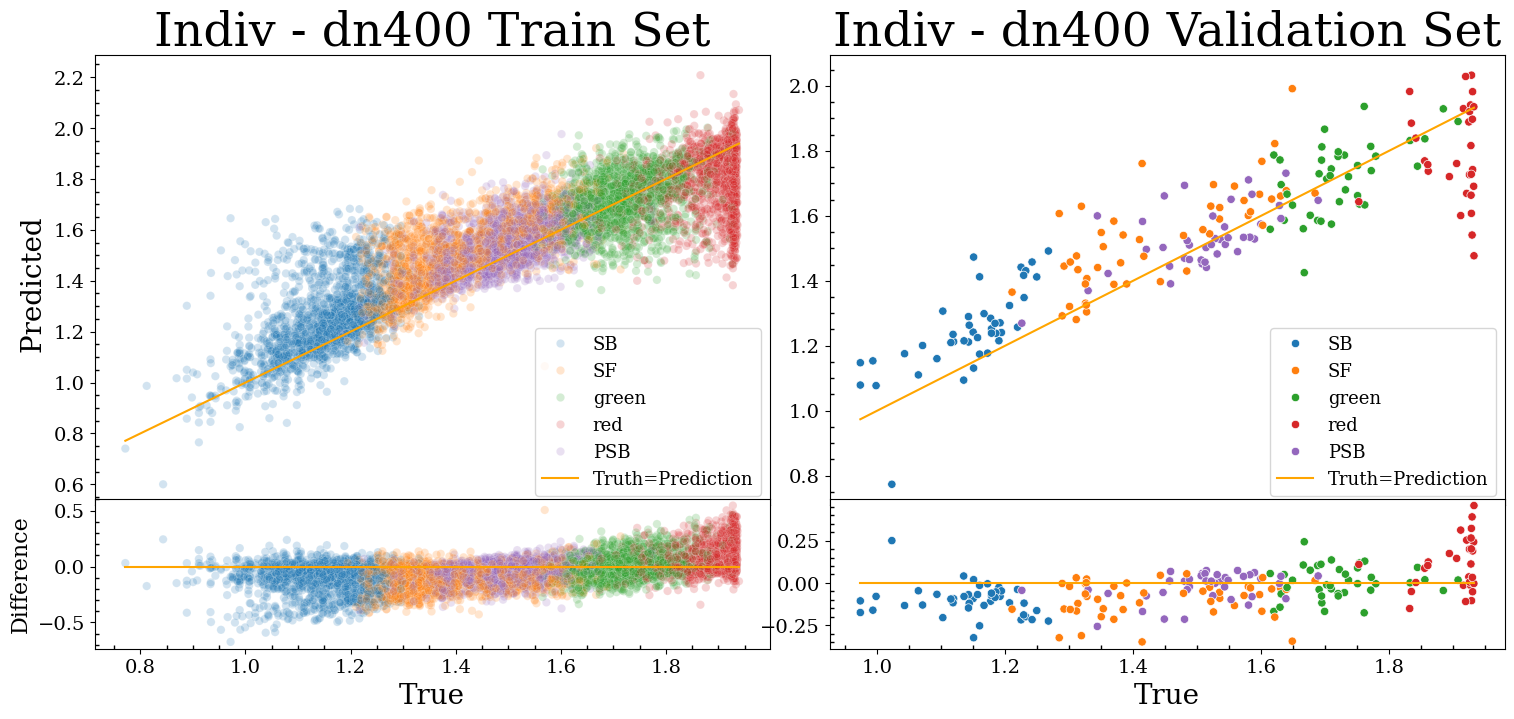

In [224]:
# plot for concat models
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
#graphPredictionTruth(*trainGraphdata_2_fgal,*validGraphdata_2_fgal, 'Indiv - fgal',ax, True, le)
graphPredictionTruth(*trainGraphdata_2_dn4,*validGraphdata_2_dn4, 'Indiv - dn400',ax, True, le)
#graphPredictionTruth(*trainGraphdata_2_hdel,*validGraphdata_2_hdel, 'Indiv - Hdelta',ax, True, le)

In [ ]:
# indiv
## input required: just flux array

model_fgal_indv
model_dn4_indv
model_hdelta_indv


# Concat- at start
## input required: just flux array + prediction from previous models as new channel

model_fgal_Version2
model_dn4000_Version2
model_hdelta_Version2

# concat - at fc
## input required: just flux array + prediction from previous models as new channel
model_fgal_Version3
model_dn4000_Version3
model_hdelta_Version3


# Simul
## input required: just flux array + prediction from previous models as new channel
model_fgal_simul
model_dn4_simul
model_hdel_simul

# poster

-1.5121581382752982
943 944
4101.0966 4102.041
0.8135601425820792 1.0204078177271403


<ipython-input-245-ea33c940f30f>:18: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(4100,4100)


(3895.0, 4305.0)

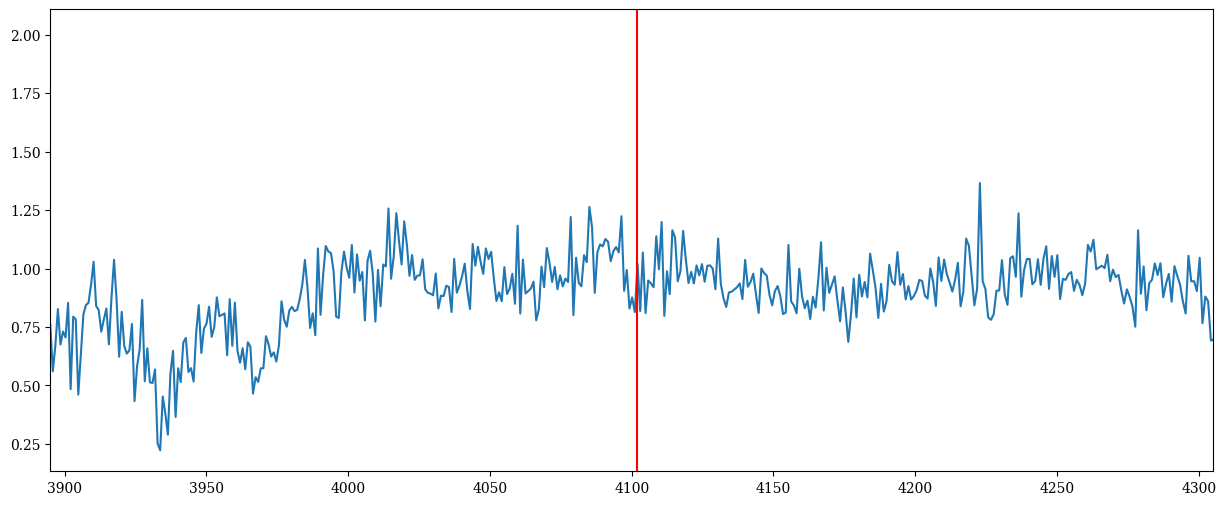

In [245]:
file_path=filePaths[1]
fig, ax =plt.subplots(figsize=(15,6))
with open(file_path, "rb") as f:
    data = pickle.load(f)
    data['wl'] = data['wl'].flatten()

    ax.plot(data['wl'], data['flux'])
    print(data['hdelta'])

plt.axvline(x=4101.734, color='red')

a=np.where(data['wl'] <= 4101.734)[0][-1]
b=np.where(data['wl'] >= 4101.734)[0][0]
print(a,b)
print(data['wl'][a],data['wl'][b])
print(data['flux'][a],data['flux'][b])

ax.set_xlim(4100,4100)


#fig.savefig('poster fig1 -1', bbox_inches='tight', dpi=1000)